# Cryptocurrency Pairs Trading Strategy

**Originally developed by Chee-Foong (EdgeTrader), May 2020**  
**Extended and adapted by Connor Greenwood-Cribbin**

---

## Overview

This notebook investigates a market-neutral pairs trading strategy using
cryptocurrency price data from Binance.

The original implementation was developed by Chee-Foong and adapted from
Auquan's article,
[Pairs Trading using Data-Driven Techniques: Simple Trading Strategies Part 3](https://medium.com/auquan/pairs-trading-data-science-7dbedafcfe5a).

Rather than applying the strategy to equities, the analysis searches for
cryptocurrency pairs that exhibit a statistically significant long-run
relationship. Candidate pairs are evaluated using historical training data,
with cointegration tests used to identify potentially mean-reverting price
relationships.

When the spread between two assets moves sufficiently far from its estimated
equilibrium, the strategy opens opposing positions:

- long one cryptocurrency;
- short the other cryptocurrency;
- size the positions using an estimated hedge ratio.

Positions are closed when the spread moves back towards its equilibrium level.
Profit and loss are calculated from the prices observed when positions are
opened and closed.

## Extensions in This Version

This version extends the original notebook through:

- analysis of a broader cryptocurrency universe;
- correlation-based preliminary pair screening;
- minimum shared-history requirements;
- BTC-focused cointegration analysis;
- revised signal and position-management logic;
- parameter evaluation across different rolling windows and thresholds;
- separate training and performance-evaluation periods;
- additional trade, holding-period and portfolio-performance diagnostics.

The original BTC/ETH specification was also reassessed after failing to provide
sufficient evidence of cointegration. Alternative pairs, including BTC/XRP,
were subsequently investigated.

## Assumptions and Limitations

The current analysis does not fully account for:

- transaction fees;
- bid-ask spreads and slippage;
- short-borrow and funding costs;
- market liquidity;
- exchange execution constraints.

Results should therefore be interpreted as an academic research exercise rather
than evidence of directly achievable live-trading performance.

## References

- Chee-Foong, *Pairs Trading Using Co-integrated Cryptocurrency Pairs*,
  EdgeTrader, 2020.
- Auquan, *Pairs Trading using Data-Driven Techniques: Simple Trading
  Strategies Part 3*.

---
## Install dependencies

In [ ]:
!pip install statsmodels

---
## Loading the libraries

In [184]:
# IMPORTS
import pandas as pd
import numpy as np

import time
import math
import os.path

from tqdm import tnrange, notebook

from datetime import timedelta, datetime
from dateutil import parser

# Import the plotting library
import matplotlib.pyplot as plt
# %matplotlib inline

import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from matplotlib.dates import MonthLocator

import seaborn as sns
sns.set()

plt.rcParams.update({'figure.figsize':(15,7), 'figure.dpi':120})
# plt.style.use('ggplot')

---
## Loading the prices downloaded from Binance

In [185]:
Input_file = os.path.join(os.path.expanduser("~"), "Desktop", "Book4.csv")


prices = pd.read_csv(Input_file, parse_dates=True, index_col='timestamp')
prices.head()

,BTC,ETH,BNB,BCC,NEO,LTC,ADA,XRP,EOS,XLM,...,ACX,BIO,TST,HEI,RED,GPS,BMT,NIL,TUT,GUN
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-01,13380.00,754.99,8.4500,2300.01,78.299,222.61,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,14675.11,855.28,8.7150,2529.01,89.696,247.33,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,14919.51,934.03,9.3040,2512.85,103.505,238.77,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,15059.54,940.00,9.1430,2331.78,97.669,233.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,16960.39,959.30,14.8908,2393.24,95.134,240.54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Extracting basic price information of the cryptocurrencies and exploring price relevance and date range of each coin.

In [186]:
data_info = []

for coin in notebook.tqdm(prices.columns):
    c = {}
    c['coin'] = coin
    c['mindate'] = prices[coin].dropna().index.min()
    c['maxdate'] = prices[coin].dropna().index.max()
    c['days'] = prices[coin].dropna().index.max() - prices[coin].dropna().index.min()
    data_info.append(c)

data_info = pd.DataFrame(data_info).sort_values('maxdate')    


  0%|          | 0/262 [00:00<?, ?it/s]

Select list of crypotocurrenices of interest based on relevance and number of days traded in the market.

Filtering criteria:
- Start date - First trading day
- End date - Last trading day
- Number of days in the market

In [ ]:
#startdate = datetime(2018,1,1)
#enddate = datetime(2024,12,31)
#numofdays = '180 days'

In [ ]:
#interested = data_info[(data_info.days > pd.Timedelta(numofdays)) & 
#                       (data_info.maxdate > enddate) &
#                       (data_info.mindate < startdate)].coin
# list(interested)

In [ ]:
#data_info[['coin','days','mindate','maxdate']]

In [187]:
#prices = prices[interested]
prices.shape

(2557, 262)

Resampling of prices:
- Daily: D
- Hourly: 1H, 4H, 6H, 12H
- Minutes: 1T, 5T, 30T

For automated trading strategies, trading signals are analysed and triggered at every time sample.  Depending on the daily resampling, this translates to the number of trading opportunities per day.  Eg: 6H will have 4 trading opportunities per day.

In [188]:
#prices = prices.resample('4H').pad()
#prices.dropna(inplace=True)

In [189]:
prices.isnull().any().any()

np.True_

In [190]:
prices.head()

,BTC,ETH,BNB,BCC,NEO,LTC,ADA,XRP,EOS,XLM,...,ACX,BIO,TST,HEI,RED,GPS,BMT,NIL,TUT,GUN
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-01,13380.00,754.99,8.4500,2300.01,78.299,222.61,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,14675.11,855.28,8.7150,2529.01,89.696,247.33,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,14919.51,934.03,9.3040,2512.85,103.505,238.77,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,15059.54,940.00,9.1430,2331.78,97.669,233.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,16960.39,959.30,14.8908,2393.24,95.134,240.54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [191]:
prices.tail()

,BTC,ETH,BNB,BCC,NEO,LTC,ADA,XRP,EOS,XLM,...,ACX,BIO,TST,HEI,RED,GPS,BMT,NIL,TUT,GUN
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-12-27,94299.03,3333.51,691.85,NaN,13.94,100.58,0.8771,2.1466,0.7848,0.3498,...,0.6514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-28,95300.00,3404.00,722.13,NaN,14.77,100.74,0.8895,2.1843,0.8085,0.3563,...,0.6002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-29,93738.20,3356.48,694.71,NaN,14.00,98.51,0.8590,2.0942,0.7765,0.3382,...,0.5852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-30,92792.05,3361.84,705.36,NaN,13.90,99.40,0.8615,2.0587,0.7736,0.3319,...,0.6123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31,93576.00,3337.78,702.30,NaN,13.55,103.28,0.8451,2.0836,0.7748,0.3327,...,0.5652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Splitting the prices to training and testing.


In [242]:
train_prices = prices['2018-05-04':'2022-12-31']
test_prices = prices['2019-01-01':'2024-12-31']

In [243]:
train_prices.head()

,BTC,ETH,BNB,BCC,NEO,LTC,ADA,XRP,EOS,XLM,...,ACX,BIO,TST,HEI,RED,GPS,BMT,NIL,TUT,GUN
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-05-04,9713.99,785.99,14.3622,1518.84,84.205,169.44,0.35800,0.88990,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-05,9864.00,819.50,14.4468,1768.00,84.500,179.04,0.36502,0.90280,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-06,9659.01,794.30,14.0120,1760.00,83.766,172.32,0.34654,0.86483,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-07,9365.00,752.49,13.7100,1650.19,79.129,164.59,0.33046,0.82490,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-08,9187.56,748.99,13.4981,1597.90,76.853,158.89,0.32213,0.80667,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [244]:
test_prices.head()

,BTC,ETH,BNB,BCC,NEO,LTC,ADA,XRP,EOS,XLM,...,ACX,BIO,TST,HEI,RED,GPS,BMT,NIL,TUT,GUN
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01,3797.14,139.10,5.9910,NaN,7.756,31.48,0.04198,0.36080,2.6184,0.11351,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,3858.56,152.01,6.0510,NaN,7.899,32.67,0.04433,0.36882,2.8197,0.11656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,3766.78,146.30,5.7979,NaN,7.522,31.39,0.04205,0.35240,2.6379,0.11139,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,3792.01,151.97,5.9692,NaN,7.455,31.76,0.04301,0.35308,2.6744,0.11271,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-05,3770.96,152.83,5.9625,NaN,7.722,34.33,0.04403,0.34851,2.6510,0.11148,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Finding Cointegration

Cointegration search functions mainly adapted from the article by Auquan - [Pairs Trading using Data-Driven Techniques: Simple Trading Strategies Part 3](https://medium.com/auquan/pairs-trading-data-science-7dbedafcfe5a).

In [105]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

In [106]:
# --- Step 1: Compute the correlation matrix and filter pairs ---
threshold = 0.98
corr_matrix = train_prices.corr()
pairs_to_test = []

for i, col1 in enumerate(train_prices.columns):
    for j, col2 in enumerate(train_prices.columns):
        if i < j and abs(corr_matrix.loc[col1, col2]) < threshold:
            pairs_to_test.append((col1, col2))

print("Pairs to test based on correlation threshold:", pairs_to_test)

Pairs to test based on correlation threshold: [('BTC', 'ETH'), ('BTC', 'BNB'), ('BTC', 'BCC'), ('BTC', 'NEO'), ('BTC', 'LTC'), ('BTC', 'ADA'), ('BTC', 'XRP'), ('BTC', 'EOS'), ('BTC', 'XLM'), ('BTC', 'ONT'), ('BTC', 'TRX'), ('BTC', 'ETC'), ('BTC', 'ICX'), ('BTC', 'VEN'), ('BTC', 'VET'), ('BTC', 'PAX'), ('BTC', 'BTT'), ('BTC', 'ONG'), ('BTC', 'HOT'), ('BTC', 'ZIL'), ('BTC', 'ZRX'), ('BTC', 'FET'), ('BTC', 'BAT'), ('BTC', 'XMR'), ('BTC', 'ZEC'), ('BTC', 'OMG'), ('BTC', 'ENJ'), ('BTC', 'ONE'), ('BTC', 'FTM'), ('BTC', 'GTO'), ('BTC', 'ERD'), ('BTC', 'WIN'), ('BTC', 'COS'), ('BTC', 'MTL'), ('BTC', 'MFT'), ('BTC', 'KEY'), ('BTC', 'WAN'), ('BTC', 'FUN'), ('BTC', 'CVC'), ('BTC', 'CHZ'), ('BTC', 'XTZ'), ('BTC', 'REN'), ('BTC', 'RVN'), ('BTC', 'NKN'), ('BTC', 'STX'), ('BTC', 'RLC'), ('BTC', 'MCO'), ('BTC', 'BCH'), ('BTC', 'FTT'), ('BTC', 'BRY'), ('BTC', 'TRY'), ('BTC', 'RUB'), ('BTC', 'EUR'), ('BTC', 'OGN'), ('BTC', 'TCT'), ('BTC', 'WRX'), ('BTC', 'BTS'), ('BTC', 'LSK'), ('BTC', 'BNT'), ('BTC', '

In [22]:
# --- Step 2: Define a filtered cointegration testing function ---
def find_cointegrated_pairs_filtered(data, pairs_to_test, conf=0.05):
    data = data.fillna(0)
    keys = data.columns
    n = len(keys)
    # Initialize matrices with NaN so that untested pairs remain empty
    score_matrix = np.full((n, n), np.nan)
    pvalue_matrix = np.full((n, n), np.nan)
    pairs = []
    for (col1, col2) in pairs_to_test:
        # Use a sensible imputation method (for example, forward-fill)
        S1 = data[col1].ffill()
        S2 = data[col2].ffill()
        # Align the series on common dates if necessary
        S1, S2 = S1.align(S2, join='inner')
        # Only test if there is sufficient overlap
        if len(S1) < 10:
            continue
        result = coint(S1, S2)
        score = result[0]
        pvalue = result[1]
        i = list(keys).index(col1)
        j = list(keys).index(col2)
        score_matrix[i, j] = score
        pvalue_matrix[i, j] = pvalue
        if pvalue < conf:
            pairs.append((col1, col2))
    return score_matrix, pvalue_matrix, pairs

In [13]:
def find_cointegrated_pairs(data, conf=0.05):
    # Drop rows with missing values across the DataFrame.
    data = data.fillna(0)
    
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < conf:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

In [14]:
def find_cointegrated_pairs_v2(data):
    n = data.shape[1]
    keys = data.keys()

    pairs = []
    scores = []
    pvalues = []
    for i in range(n):
        for j in range(i+1, n):
            try:
                S1 = data[keys[i]]
                S2 = data[keys[j]]
                result = coint(S1, S2)
                scores.append(result[0])
                pvalues.append(result[1])
                pairs.append((keys[i], keys[j]))
            except ValueError as error:
                print(error)
                pass
                      
    return scores, pvalues, pairs

In [15]:
def search_coint_pairs_v2(prices_df, conf=0.05):
    
    scores, pvalues, pairs = find_cointegrated_pairs_v2(prices_df)
    coint_pairs = pd.DataFrame(list(zip(scores, pvalues, pairs)), 
                               columns=['scores','pvalues','pairs'])

    return coint_pairs.sort_values('pvalues')

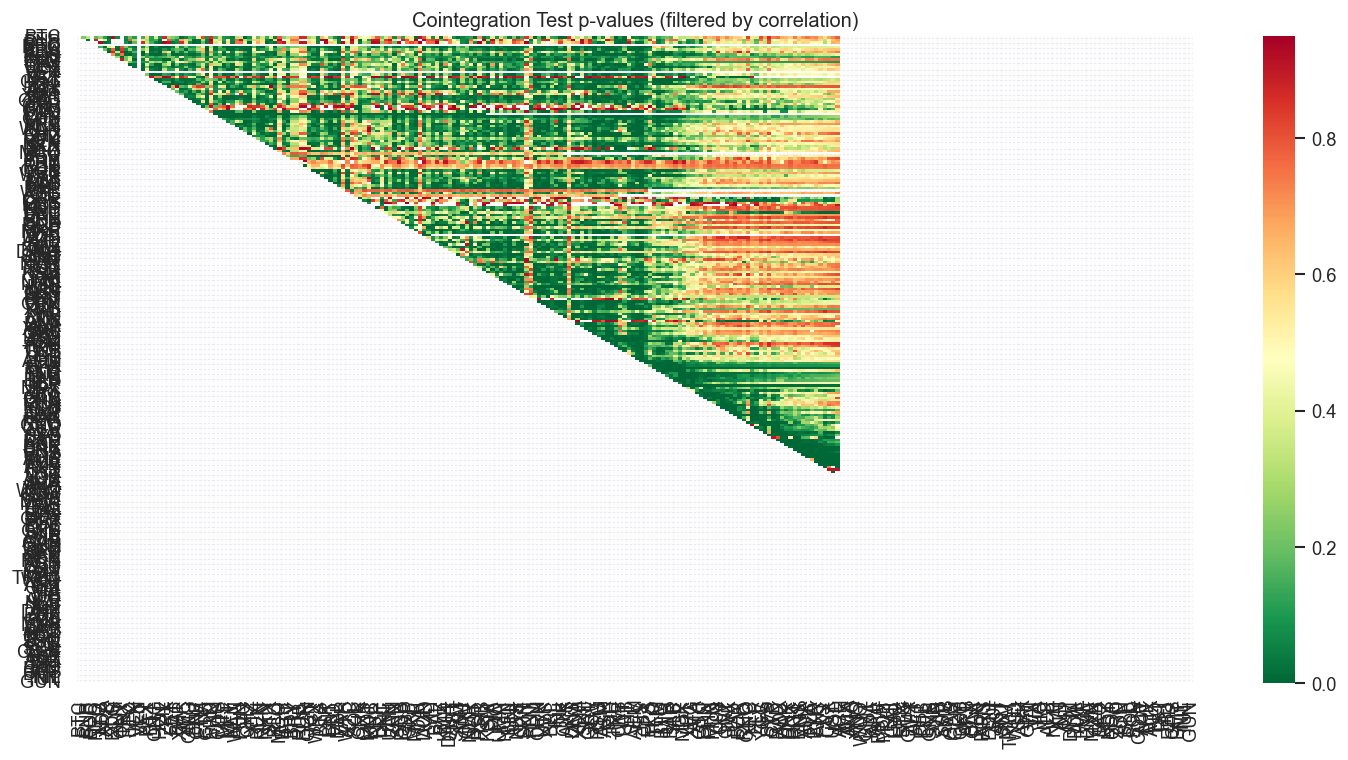

Cointegrated pairs (p-value < 0.05):
[('BTC', 'XRP'), ('BTC', 'XMR'), ('BTC', 'CVC'), ('BTC', 'RLC'), ('BTC', 'MBL'), ('BTC', 'MKR'), ('BTC', 'BLZ'), ('BTC', 'SRM'), ('BTC', 'ANT'), ('BTC', 'DOT'), ('BTC', 'TRB'), ('BTC', 'BEL'), ('BTC', 'NBS'), ('BTC', 'FLM'), ('BTC', 'UTK'), ('BTC', 'INJ'), ('BTC', 'CTK'), ('BTC', 'JUV'), ('BTC', 'TRU'), ('BTC', 'TWT'), ('BTC', 'SFP'), ('BTC', 'FIS'), ('ETH', 'BNB'), ('ETH', 'XRP'), ('ETH', 'HOT'), ('ETH', 'ENJ'), ('ETH', 'ONE'), ('ETH', 'GTO'), ('ETH', 'NKN'), ('ETH', 'STX'), ('ETH', 'MBL'), ('ETH', 'CHR'), ('ETH', 'CRV'), ('ETH', 'HNT'), ('ETH', 'TRU'), ('ETH', 'CKB'), ('ETH', 'TWT'), ('ETH', 'TLM'), ('ETH', 'GTC'), ('BNB', 'ADA'), ('BNB', 'XRP'), ('BNB', 'ETC'), ('BNB', 'ONG'), ('BNB', 'HOT'), ('BNB', 'FET'), ('BNB', 'ENJ'), ('BNB', 'ONE'), ('BNB', 'GTO'), ('BNB', 'KEY'), ('BNB', 'CHZ'), ('BNB', 'NKN'), ('BNB', 'RLC'), ('BNB', 'MBL'), ('BNB', 'CHR'), ('BNB', 'CRV'), ('BNB', 'KSM'), ('BNB', 'PSG'), ('BNB', 'ATM'), ('BNB', 'TRU'), ('BNB', 'CKB'), ('

In [23]:
# Run the filtered cointegration tests
scores, pvalues, pairs = find_cointegrated_pairs_filtered(train_prices, pairs_to_test, conf=0.05)

# --- Step 3: Plot the heatmap of p-values ---
plt.figure(figsize=(15,7))
sns.heatmap(pvalues,
            xticklabels=train_prices.columns, 
            yticklabels=train_prices.columns, 
            cmap='RdYlGn_r', 
            mask = (pvalues >= 0.95))  # Mask out high p-values
plt.title("Cointegration Test p-values (filtered by correlation)")
plt.show()

print("Cointegrated pairs (p-value < 0.05):")
print(pairs)

Cointergrated pairs have p-values close to zero.  Above heatmap shows the list of cointegrated pairs that potentially could be considered for this pair trading strategy.

In [28]:
import pandas as pd
import numpy as np

# 'keys' are the column names from train_prices
keys = list(train_prices.columns)
pair_info = []

# Loop over the upper triangle of the pvalue_matrix
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        pval = pvalues[i, j]
        # Only include pairs where we have a valid p-value
        if not np.isnan(pval):
            pair_info.append({"pair": (keys[i], keys[j]), "pvalue": pval})

# Create a DataFrame of all tested pairs with their p-values
pair_df = pd.DataFrame(pair_info)

# Now filter for pairs that include 'BTC'
btc_pair_df = pair_df[pair_df["pair"].apply(lambda x: "BTC" in x)]

# Sort the results by ascending p-value (best cointegration first)
btc_pair_df_sorted = btc_pair_df.sort_values("pvalue")

print("Cointegrated pairs with BTC (sorted by p-value):")
print(btc_pair_df_sorted)


Cointegrated pairs with BTC (sorted by p-value):
           pair    pvalue
110  (BTC, INJ)  0.000086
118  (BTC, JUV)  0.000220
123  (BTC, TRU)  0.001565
36   (BTC, CVC)  0.002669
90   (BTC, DOT)  0.003367
..          ...       ...
61   (BTC, XZC)  0.871885
59   (BTC, ZAR)  0.897601
77   (BTC, DAI)  0.915864
6    (BTC, EOS)  0.925682
8    (BTC, ONT)  0.958103

[176 rows x 2 columns]


In [30]:
def get_overlap_count(data, coin_pair):
    asset1, asset2 = coin_pair
    # Replace zeros with NaN and drop NaN values
    s1 = data[asset1].replace(0, np.nan).dropna()
    s2 = data[asset2].replace(0, np.nan).dropna()
    # Align the two series on their common index
    s1, s2 = s1.align(s2, join='inner')
    return len(s1)

# Append a new column 'n_points' to the btc_pair_df_sorted DataFrame
btc_pair_df_sorted["n_points"] = btc_pair_df_sorted["pair"].apply(lambda x: get_overlap_count(train_prices, x))

print(btc_pair_df_sorted)

           pair    pvalue  n_points
110  (BTC, INJ)  0.000086       437
118  (BTC, JUV)  0.000220       376
123  (BTC, TRU)  0.001565       347
36   (BTC, CVC)  0.002669       858
90   (BTC, DOT)  0.003367       501
..          ...       ...       ...
61   (BTC, XZC)  0.871885       294
59   (BTC, ZAR)  0.897601       372
77   (BTC, DAI)  0.915864        21
6    (BTC, EOS)  0.925682      1096
8    (BTC, ONT)  0.958103      1096

[176 rows x 3 columns]


In [33]:
btc_pair_df_filtered = btc_pair_df_sorted[btc_pair_df_sorted["n_points"] >= 1096]
print(btc_pair_df_filtered)


          pair    pvalue  n_points
5   (BTC, XRP)  0.014556      1096
7   (BTC, XLM)  0.065151      1096
9   (BTC, TRX)  0.071460      1096
11  (BTC, ICX)  0.106571      1096
4   (BTC, ADA)  0.112589      1096
12  (BTC, VET)  0.149006      1096
2   (BTC, NEO)  0.176651      1096
10  (BTC, ETC)  0.196823      1096
0   (BTC, ETH)  0.231624      1096
3   (BTC, LTC)  0.262882      1096
1   (BTC, BNB)  0.339683      1096
6   (BTC, EOS)  0.925682      1096
8   (BTC, ONT)  0.958103      1096


Selecting the best pair for analysis

In [107]:
# Assuming btc_pair_df_filtered (or btc_pair_df_sorted) contains only BTC pairs sorted by p-value:
if not btc_pair_df_filtered.empty:
    chosen_pair = btc_pair_df_filtered.iloc[0]["pair"]
else:
    raise ValueError("No cointegrated pairs with BTC found!")

P1, P2 = chosen_pair
print('Selected pair with lowest p-value: {} vs {}'.format(P1, P2))

Selected pair with lowest p-value: BTC vs XRP


In [108]:
# Get the corresponding series from train_prices.
S1 = train_prices[P1].replace(0, np.nan).ffill().dropna()
S2 = train_prices[P2].replace(0, np.nan).ffill().dropna()

# Print last available price for each coin.
print('Last price of {}: {} vs Last price of {}: {}'.format(P1, S1.iloc[-1], P2, S2.iloc[-1]))


Last price of BTC: 16542.4 vs Last price of XRP: 0.3389


In [109]:
# Run the cointegration test (for confirmation).
score, pvalue, _ = coint(S1, S2)
print("Cointegration test statistic: {:.4f}, p-value: {:.4f}".format(score, pvalue))

# Calculate the ratio of the two series.
ratios = S1 / S2

Cointegration test statistic: -3.8313, p-value: 0.0123


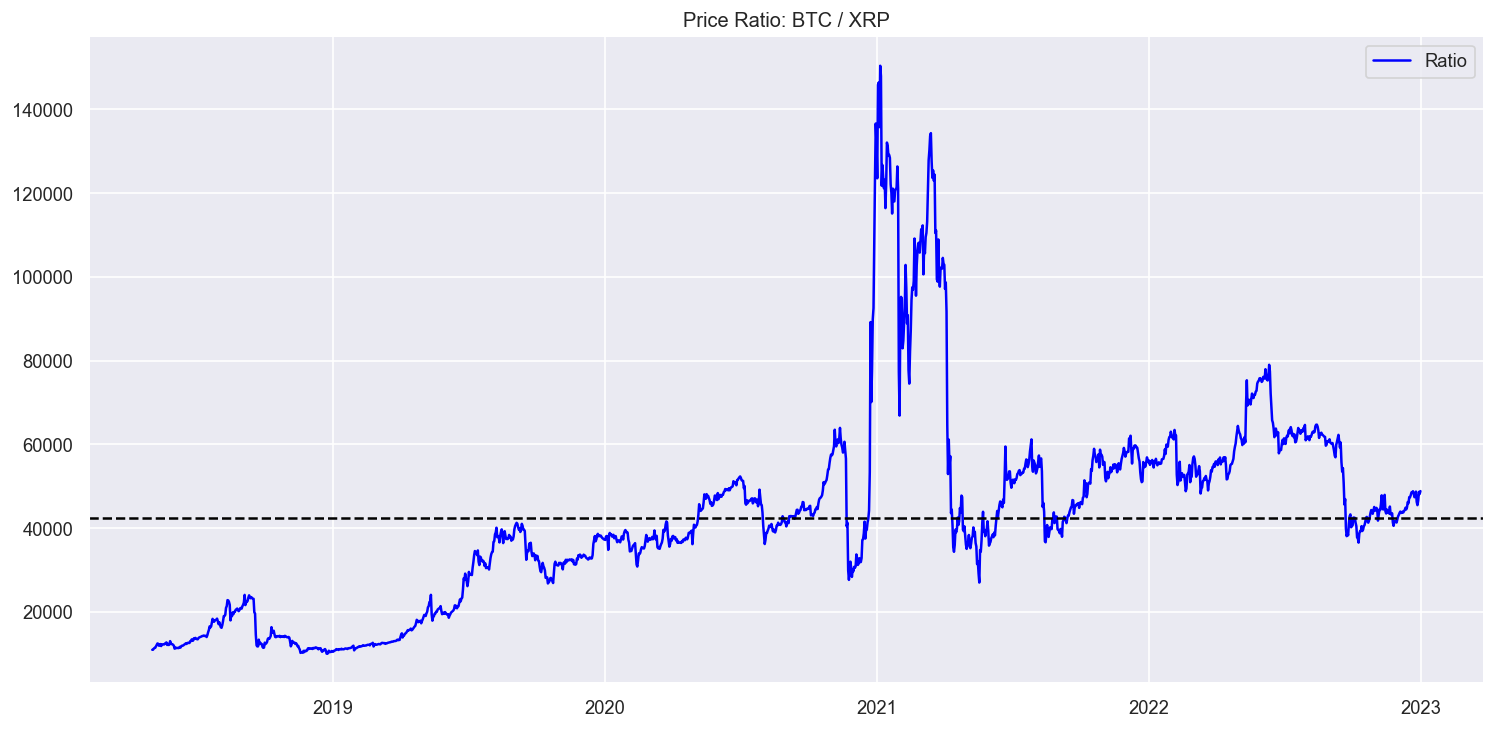

Mean ratio: 42499.99


In [110]:
plt.figure(figsize=(15,7))
plt.plot(ratios.index, ratios, color='blue')
plt.axhline(ratios.mean(), color='black', linestyle='--')
plt.legend(['Ratio'])
plt.title("Price Ratio: {} / {}".format(P1, P2))
plt.show()

print('Mean ratio: {:.2f}'.format(ratios.mean()))

We should expect the ratio to move around a stable mean.  Normalising the ratio below.

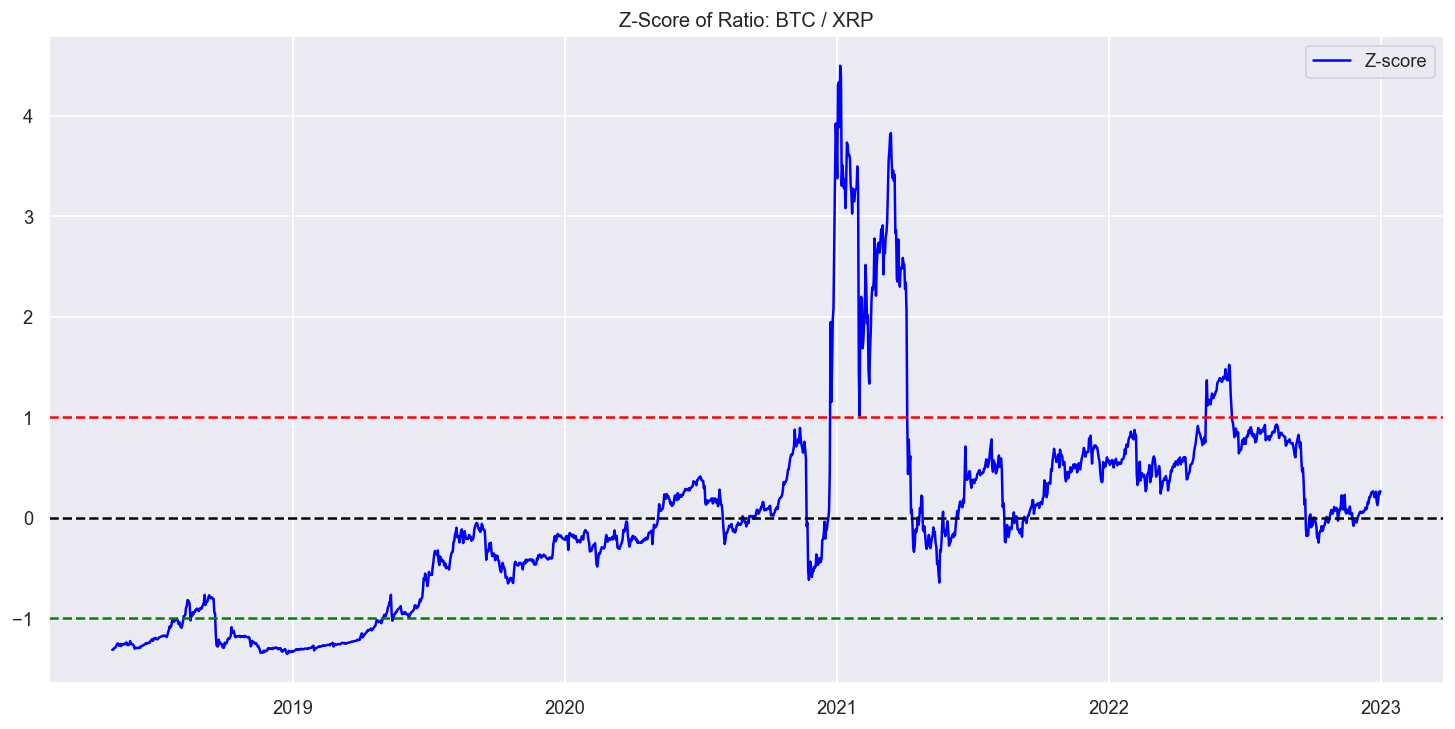

In [111]:
# Define the zscore function.
def zscore(series):
    return (series - series.mean()) / np.std(series)

# Plot the zscore of the ratio.
z_ratios = zscore(ratios)
plt.figure(figsize=(15,7))
plt.plot(z_ratios.index, z_ratios, color='blue')
plt.axhline(z_ratios.mean(), color='black', linestyle='--')
plt.axhline(1.0, color='red', linestyle='--')
plt.axhline(-1.0, color='green', linestyle='--')
plt.legend(['Z-score'])
plt.title("Z-Score of Ratio: {} / {}".format(P1, P2))
plt.show()

We should expect the ratio's z-score to oscillate between the mean of zero.  When there is huge divergence, there will be trading opportunities.

## Feature Engineering

The strategy aims to identify temporary deviations in the relative value of the
two cryptocurrencies. For a pair that has passed the cointegration screening
process, the trading model assumes that its price ratio may exhibit
mean-reverting behaviour.

Rather than estimating the mean and standard deviation over the entire sample,
rolling statistics are used so that the signal responds to more recent market
conditions.

The following features are calculated:

- **Long-term moving average (60MA):** the 60-day moving average of the price ratio.
- **Rolling standard deviation (60SD):** the 60-day standard deviation of the price ratio.
- **Short-term moving average (5MA):** the 5-day moving average of the price ratio.
- **Rolling z-score:** the difference between the short-term and long-term moving
  averages, scaled by the 60-day rolling standard deviation.

The z-score is calculated as:

\[
Z_t = \frac{5MA_t - 60MA_t}{60SD_t}
\]

A positive z-score indicates that the short-term ratio is above its longer-term
average, while a negative z-score indicates that it is below its longer-term
average.

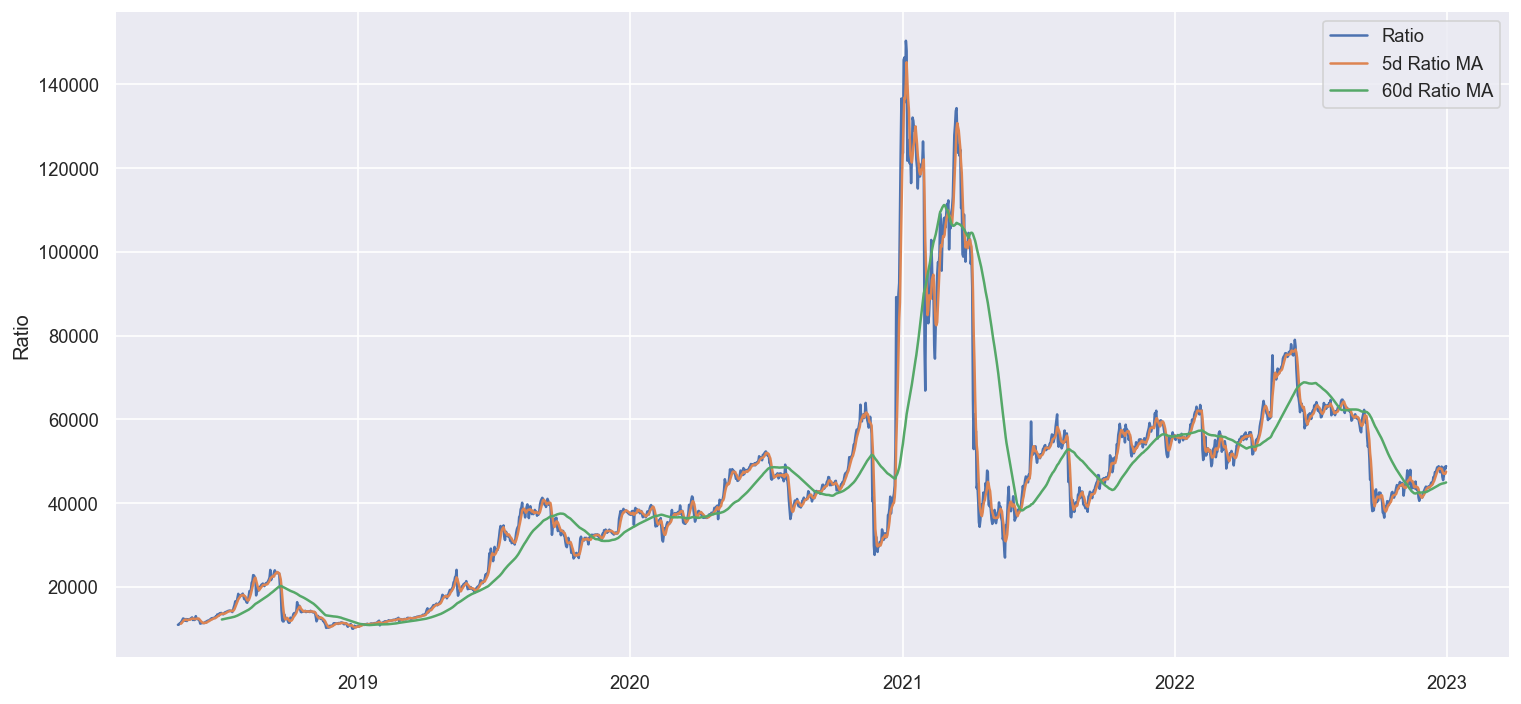

In [195]:
ratios_mavg5 = ratios.rolling(window=5, center=False).mean()
ratios_mavg60 = ratios.rolling(window=60, center=False).mean()
std_60 = ratios.rolling(window=60, center=False).std()
zscore_60_5 = (ratios_mavg5 - ratios_mavg60)/std_60

plt.figure(figsize=(15,7))
plt.plot(ratios.index, ratios.values)
plt.plot(ratios_mavg5.index, ratios_mavg5.values)
plt.plot(ratios_mavg60.index, ratios_mavg60.values)
plt.legend(['Ratio','5d Ratio MA', '60d Ratio MA'])
plt.ylabel('Ratio')
plt.show()

The 5-day moving average represents the recent behaviour of the ratio, while
the 60-day moving average provides a longer-term reference level.

Under the strategy's mean-reversion assumption, periods in which the short-term
average moves materially away from the long-term average may create potential
trading opportunities. The strategy expects this divergence eventually to
narrow.

Persistent divergence is a risk because it can:

- extend the length of time that a position remains open;
- increase unrealised losses;
- indicate that the historical relationship between the two assets has weakened
  or changed.

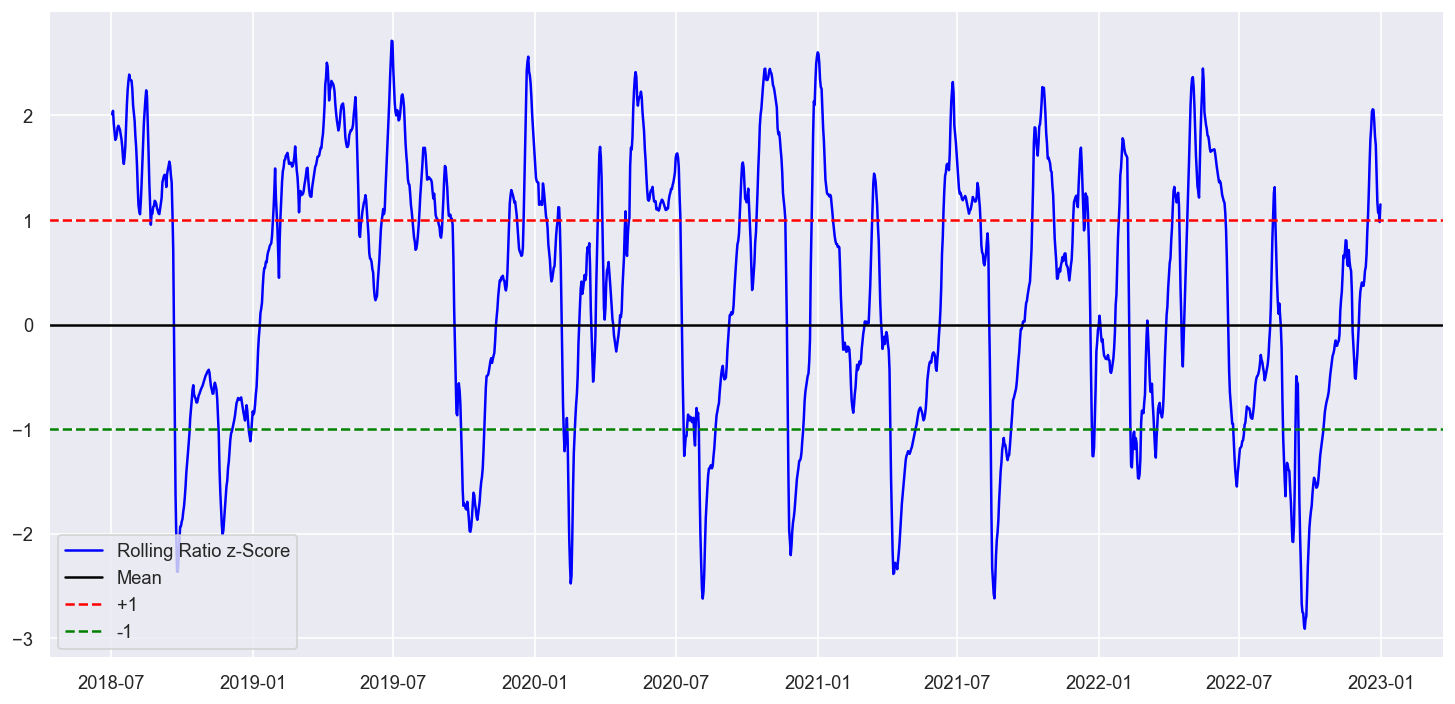

In [196]:
plt.figure(figsize=(15,7))

plt.plot(zscore_60_5.index, zscore_60_5, color='blue')

plt.axhline(0, color='black')
plt.axhline(1.0, color='red', linestyle='--')
plt.axhline(-1.0, color='green', linestyle='--')
plt.legend(['Rolling Ratio z-Score', 'Mean', '+1', '-1'])
plt.show()

## Z-Score Interpretation

The rolling z-score measures how far the short-term price ratio has moved from
its longer-term average, relative to recent volatility.

Under the mean-reversion assumption, the z-score is expected to move back
towards zero following a sufficiently large deviation.

The initial candidate signal thresholds are:

- **Z-score greater than or equal to +1:** sell the ratio by shorting Coin 1
  and buying Coin 2.
- **Z-score less than or equal to -1:** buy the ratio by buying Coin 1
  and shorting Coin 2.
- **Z-score near zero:** the relative-price deviation has narrowed and may
  provide an exit signal in the full trading strategy.

These thresholds identify potential trading conditions. The final trading
function separately determines when positions are opened and closed.

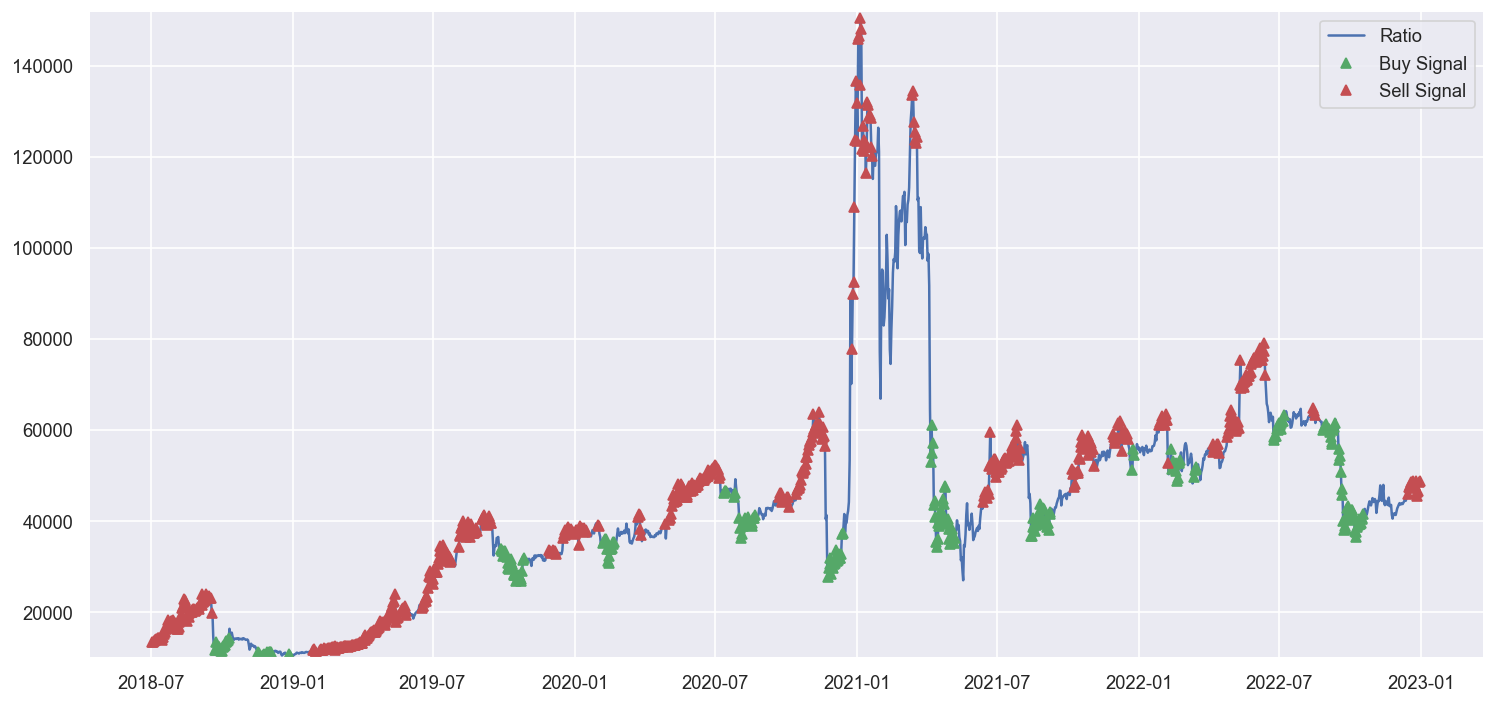

In [197]:
# Plot the ratios and buy and sell signals from z score
plt.figure(figsize=(15,7))

plt.plot(ratios[60:].index, ratios[60:])

buy = ratios.copy()
sell = ratios.copy()
buy[zscore_60_5>-1] = 0
sell[zscore_60_5<1] = 0

plt.plot(buy[60:].index, buy[60:], color='g', linestyle='None', marker='^')
plt.plot(sell[60:].index, sell[60:], color='r', linestyle='None', marker='^')

x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,ratios[60:].min()*0.99,ratios[60:].max()*1.01))
plt.legend(['Ratio', 'Buy Signal', 'Sell Signal'])
plt.show()

## Visualising Candidate Signals

The chart highlights observations where the rolling z-score crosses
the candidate entry thresholds:

- green markers indicate periods where the ratio may be bought;
- red markers indicate periods where the ratio may be sold.

Because the condition is evaluated on every observation, consecutive markers
may represent the continuation of the same signal rather than separate trades.
The chart is therefore a visualisation of signal conditions, not a complete
transaction record.

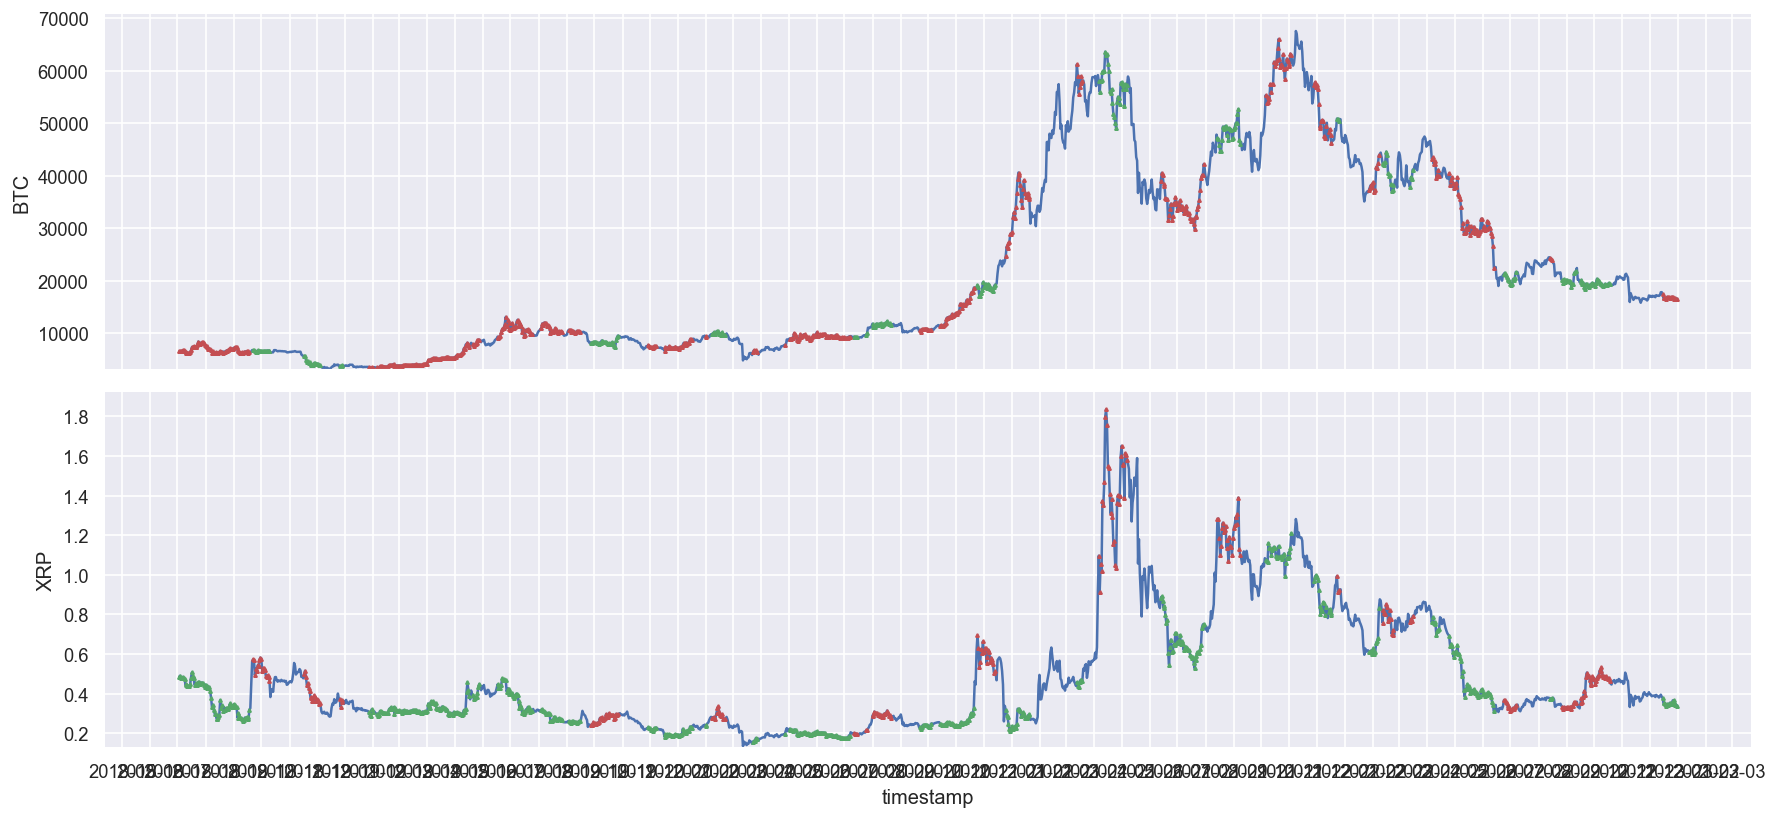

In [198]:
# Plot the prices and buy and sell signals from z score

buyS1 = 0*S1.copy()
sellS1 = 0*S1.copy()
buyS2 = 0*S2.copy()
sellS2 = 0*S2.copy()

# # When buying the ratio, buy S1 and sell S2
buyS1[buy!=0] = S1[buy!=0]
sellS2[buy!=0] = S2[buy!=0]

# # When selling the ratio, sell S1 and buy S2 
buyS2[sell!=0] = S2[sell!=0]
sellS1[sell!=0] = S1[sell!=0]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.set_ylabel(P1)
ax1.plot(S1[60:].index, S1[60:], color='b')
ax1.tick_params(axis='y')
ax1.plot(S1[60:].index, buyS1[60:], color='g', linestyle='None', marker='^', markersize=2)
ax1.plot(S1[60:].index, sellS1[60:], color='r', linestyle='None', marker='^', markersize=2)
ax1.set_ylim([min(S1[60:])*0.95, max(S1[60:])*1.05])

ax2.set_ylabel(P2)  # we already handled the x-label with ax1
ax2.plot(S2[60:].index, S2[60:], color='b')
ax2.tick_params(axis='y')
ax2.plot(S2[60:].index, buyS2[60:], color='g', linestyle='None', marker='^', markersize=2)
ax2.plot(S2[60:].index, sellS2[60:], color='r', linestyle='None', marker='^', markersize=2)
ax2.set_ylim([min(S2[60:])*0.95, max(S2[60:])*1.05])

ax2.set_xlabel('timestamp')

# Define the date format
date_form = DateFormatter("%Y-%m")
ax2.xaxis.set_major_formatter(date_form)
locator = MonthLocator()
ax2.xaxis.set_major_locator(locator)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

Similarly, the above plots show that buying and selling signals of each pairs.  It is best to observe both prices move in tandem with minimal deviation.

---
## Trading Strategy

The strategy opens a pairs trade when the rolling z-score moves beyond a
specified entry threshold and no position is currently open.

### Signal

The trading signal is based on the relative price ratio between Coin 1 and
Coin 2:

\[
R_t = \frac{P_{1,t}}{P_{2,t}}
\]

Two rolling moving averages are calculated from this ratio:

- **Near MA:** a short-term moving average of the price ratio.
- **Far MA:** a longer-term moving average representing the strategy's
  estimated equilibrium level.

The rolling z-score is calculated as:

\[
Z_t =
\frac{\text{Near MA}_t - \text{Far MA}_t}
{\text{Rolling Standard Deviation}_t}
\]

The standard deviation is calculated using the same rolling window as the
Far MA.

### Entry and Exit Rules

A new position is opened only when no existing position is held.

- **Buy the ratio:** when \(Z_t < -1\)
- **Sell the ratio:** when \(Z_t > 1\)
- **Close all positions:** when a position is open and
  \(|Z_t| < 0.75\)

The entry rules assume that a sufficiently large deviation between the
short-term and long-term ratio will eventually narrow.

### Trade Construction

Let:

\[
n_t = \frac{P_{1,t}}{P_{2,t}}
\]

where \(n_t\) is the price ratio observed when the trade is opened.

For a **buy signal**:

- buy 1 unit of Coin 1;
- short \(n_t\) units of Coin 2.

For a **sell signal**:

- short 1 unit of Coin 1;
- buy \(n_t\) units of Coin 2.

Using the current price ratio makes the initial gross notional value of the
two legs approximately equal. In this implementation, the ratio is recalculated
at each entry rather than estimated through a regression-based hedge ratio.

### Function Parameters

The `trade` function accepts the following parameters:

1. **P1**  
   The symbol for Coin 1.

2. **P2**  
   The symbol for Coin 2.

3. **near**  
   The short-term moving-average window used to represent recent movements
   in the price ratio.

4. **far**  
   The long-term moving-average and standard-deviation window used to estimate
   the ratio's longer-term reference level.

5. **test**  
   Defaults to `False`. When `False`, the function uses the training dataset.
   When `True`, it uses the testing dataset.

6. **verbose**  
   Defaults to `False`. When enabled, the function prints whether the strategy
   is being applied to the training or testing dataset.

### Transaction Logging

Each entry and exit is recorded with:

- execution date;
- asset prices and quantities;
- z-score at execution;
- price ratio used for position sizing;
- cumulative realised profit and loss;
- gross entry notional;
- holding period;
- an adverse-position-value measure recorded while the trade is open.

The reported profit and loss is updated when trades are opened or closed.
The output is therefore a transaction-level record rather than a continuous
daily marked-to-market portfolio equity series.

Transaction fees, bid-ask spreads, slippage, funding costs and short-borrow
constraints are not included.

In [289]:
from datetime import timedelta

# Trade using a simple strategy, with logging of entry_value
def trade(P1, P2, near, far, test=False, verbose=False):
    # If window length is 0, or near is not less than far, exit
    if (near == 0) or (far == 0) or (near >= far):
        return 0
    
    # Select prices: train or test data
    if test:
        if verbose:
            print('Trade on Testing Data\n')
        price1 = test_prices[P1]
        price2 = test_prices[P2]    
    else:
        if verbose:
            print('Trade on Training Data\n')
        price1 = train_prices[P1]
        price2 = train_prices[P2]
    
    # Compute rolling means, standard deviation, and z-score of the ratio
    ratios = price1 / price2
    ma1 = ratios.rolling(window=near, center=False).mean()
    ma2 = ratios.rolling(window=far, center=False).mean()
    std = ratios.rolling(window=far, center=False).std()
    zscore = (ma1 - ma2) / std
    
    # Start with no money and no positions
    money = 0
    countS1 = 0
    countS2 = 0
    drawdown = 0
    transactions = []
    opendatetime = None  # to record when a trade is opened
    entry_value = None   # to record the value at entry
    
    # Updated logging function includes entry_value
    def logTxn(datetime, action1, coin1, price1, qty1,
               action2, coin2, price2, qty2, zscore_val, hedgeratio, pnl, entry_value, drawdown=0, holdingperiod=timedelta(0)):
        txn = {}
        txn['datetime'] = datetime
        txn['action1'] = action1
        txn['coin1'] = coin1
        txn['price1'] = price1
        txn['qty1'] = qty1
        txn['action2'] = action2
        txn['coin2'] = coin2
        txn['price2'] = price2
        txn['qty2'] = qty2
        txn['zscore'] = zscore_val
        txn['hedgeratio'] = hedgeratio
        txn['pnl'] = pnl
        txn['entry_value'] = entry_value
        txn['drawdown'] = drawdown
        txn['holdingperiod'] = holdingperiod
        return txn
    
    # Simulate trading period by period using signals based on available information
    for i in range(len(ratios)):
        # Sell short if z-score > 1 and no position is open
        if (zscore[i] > 1) and (countS1 == 0) and (countS2 == 0):
            money += price1[i] - price2[i] * ratios[i]
            countS1 -= 1
            countS2 += ratios[i]
            opendatetime = ratios.index[i]
            # Compute entry_value as the total absolute value of the positions
            entry_value = abs(price1[i] * countS1) + abs(price2[i] * countS2)
            transactions.append(
                logTxn(opendatetime, 
                       'Sell', P1, price1[i], countS1,
                       'Buy', P2, price2[i], countS2, 
                       zscore[i], ratios[i], money, entry_value)
            )
                            
        # Buy long if z-score < -1 and no position is open
        elif (zscore[i] < -1) and (countS1 == 0) and (countS2 == 0):
            money -= price1[i] - price2[i] * ratios[i]
            countS1 += 1
            countS2 -= ratios[i]
            opendatetime = ratios.index[i]
            entry_value = abs(price1[i] * countS1) + abs(price2[i] * countS2)
            transactions.append(
                logTxn(opendatetime, 
                       'Buy', P1, price1[i], countS1,
                       'Sell', P2, price2[i], countS2, 
                       zscore[i], ratios[i], money, entry_value)
            )
            
        # Close all positions if the z-score is near zero (e.g. abs(zscore) < 0.75)
        elif (abs(zscore[i]) < 0.75) and ((countS1 != 0) or (countS2 != 0)):
            money += price1[i] * countS1 + price2[i] * countS2
            closedatetime = ratios.index[i]
            holdingperiod = closedatetime - opendatetime if opendatetime is not None else timedelta(0)
            # Use the previously recorded entry_value for this trade
            transactions.append(
                logTxn(closedatetime, 
                       'Close', P1, price1[i], countS1,
                       'Close', P2, price2[i], countS2, 
                       zscore[i], ratios[i], money, entry_value, min(money, drawdown), holdingperiod)
            )
            
            # Reset positions and drawdown
            countS1 = 0
            countS2 = 0
            drawdown = 0
            
        # Track maximum drawdown when positions are held
        else:            
            drawdown = min(price1[i] * countS1 + price2[i] * countS2, drawdown)
            
    return transactions

In [290]:
def showResults(txn):
    from matplotlib.dates import DateFormatter, MonthLocator
    txn = pd.DataFrame.from_dict(txn)
    txn = txn[['datetime', 'action1', 'coin1', 'price1', 'qty1',
               'action2', 'coin2', 'price2', 'qty2', 
               'zscore', 'hedgeratio', 'pnl', 'entry_value', 'drawdown', 'holdingperiod']]
    txn = txn.set_index('datetime')    
    
    plt.figure(figsize=(15,7))
    plt.plot(txn.pnl.index, txn.pnl)    

    ax = plt.gca()
    formatter = DateFormatter("%Y-%m")
    ax.xaxis.set_major_formatter(formatter)
    locator = MonthLocator()
    ax.xaxis.set_major_locator(locator)    
    
    plt.show()

    print('Profit/Loss: {:.2f}'.format(txn.iloc[-1].pnl))
    print('Maximum Drawdown: {:.2f}'.format(min(txn.drawdown)))
    print('Maximum Holding Period: {}'.format(max(txn.holdingperiod)))
    
    return txn

---
## Parameter Search

The parameter search evaluates different combinations of short-term and
long-term moving-average windows using the training dataset.

The candidate ranges are:

- **Near MA:** 5 to 14 observations
- **Far MA:** 50 to 89 observations

Only combinations where the Near MA is shorter than the Far MA are valid.

For each parameter combination, the strategy records:

- final cumulative realised profit and loss;
- the most negative open-position value recorded by the strategy;
- a custom return-to-adverse-excursion score.

The score is calculated as:

\[
\text{Score} =
\frac{\text{Final P\&L}}
{|\text{Worst Recorded Adverse Position Value}|}
\]

The parameter combination with the highest score is selected.

This objective rewards parameter combinations that produce greater realised
profit relative to the strategy's recorded adverse movement. It is not a
Sharpe ratio and should not be interpreted as a complete measure of
risk-adjusted performance.

Because the parameters are selected using the training data, their performance
may be sensitive to the chosen sample period. The selected parameters should
therefore be assessed separately on data that were not used during the search.

In [247]:
import itertools 

near = list(range(5,15,1))
far = list(range(50,90,1))

combine = [near,far]
params = list(itertools.product(*combine)) 

In [248]:
search_results = []

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


for param in notebook.tqdm(params):
    result = {}
    txn = trade(P1, P2, param[0], param[1])
    
    txn = pd.DataFrame.from_dict(txn)
    txn = txn[['datetime', 'action1', 'coin1', 'price1', 'qty1',
               'action2', 'coin2', 'price2', 'qty2', 
               'zscore', 'hedgeratio', 'pnl', 'drawdown', 'holdingperiod']]
    txn = txn.set_index('datetime')    

    result['parameter'] = param
    result['PnL'] = txn.iloc[-1].pnl
    result['max_drawdown'] = min(txn.drawdown)
    result['score'] = result['PnL']/abs(result['max_drawdown'])
    
    search_results.append(result)

  0%|          | 0/400 [00:00<?, ?it/s]

In [249]:
best = pd.DataFrame(search_results).sort_values('score', ascending=False).reset_index().parameter[0]

In [250]:
print('Best Parameters: Near: {}, Far: {}'.format(best[0], best[1]))

Best Parameters: Near: 13, Far: 75


---
## Trading on Training Data

Trade on training data using the best parameters and show the results

In [291]:
txn = trade(P1, P2, best[0], best[1])

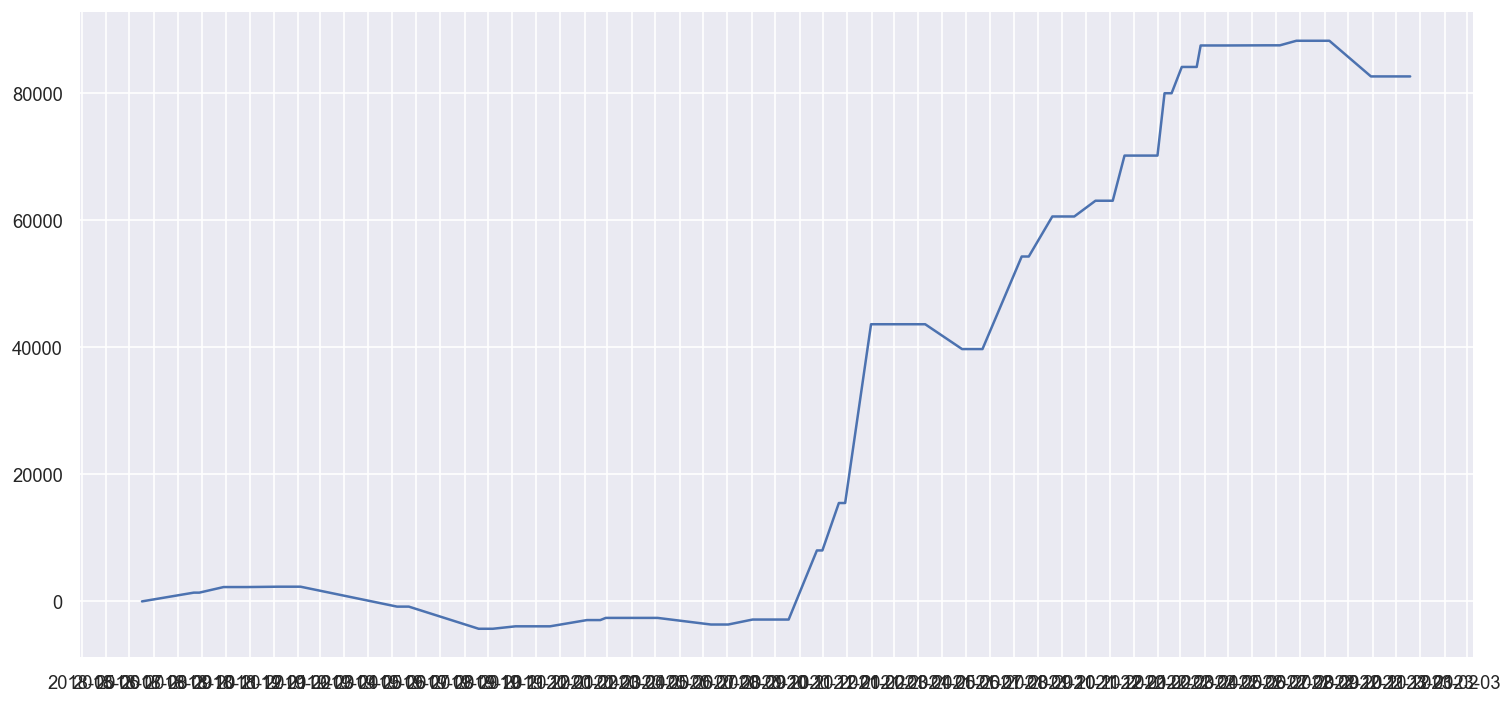

Profit/Loss: 82624.67
Maximum Drawdown: -26327.94
Maximum Holding Period: 123 days 00:00:00


In [292]:
train_results = showResults(txn)

---
## Out-Of-Sample Result

Trade on testing data using the best parameters and show the results

In [293]:
txn = trade(P1, P2, best[0], best[1], test=True)

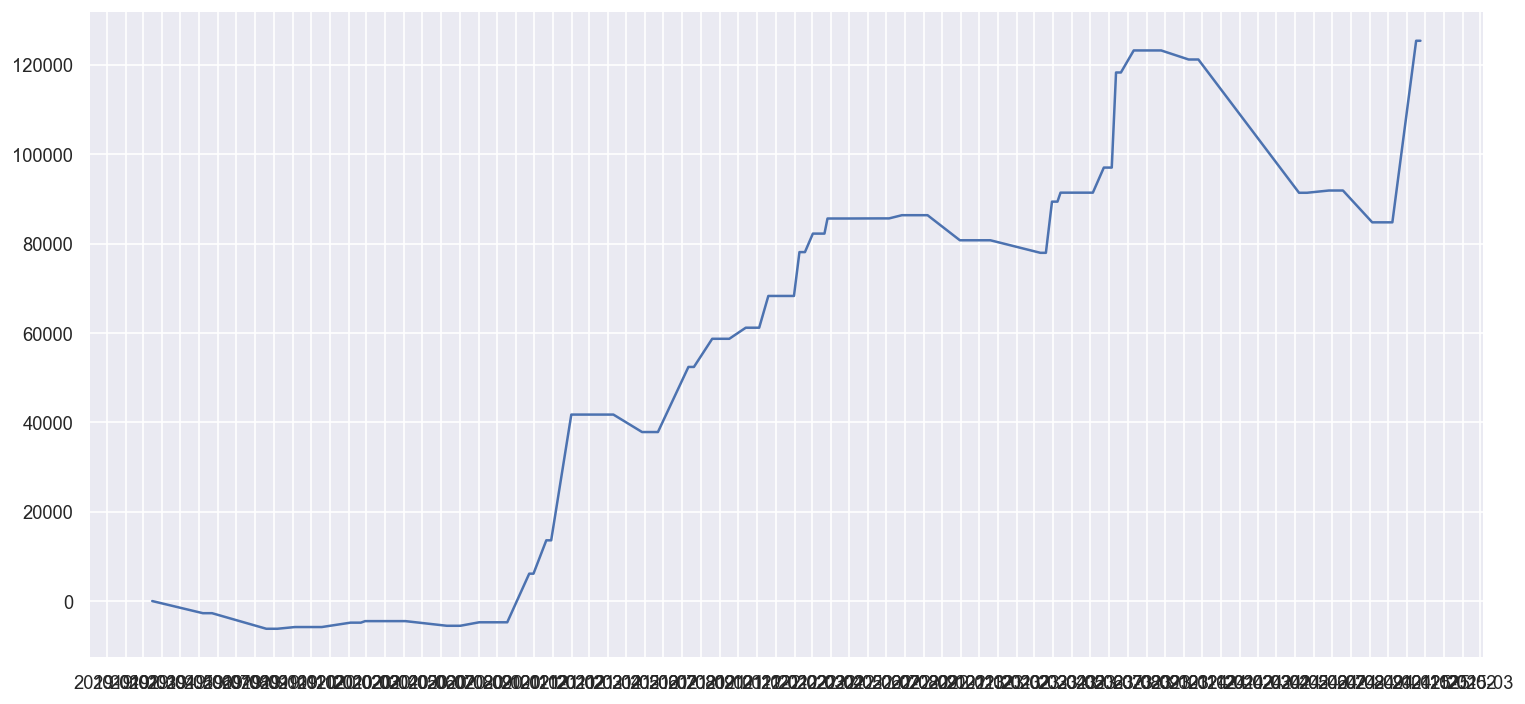

Profit/Loss: 125375.50
Maximum Drawdown: -35130.35
Maximum Holding Period: 165 days 00:00:00


In [294]:
test_results = showResults(txn)

---
## Transaction logs

Showing the transaction logs for validation purpose

### Transaction log for in-sample (train) dataset

In [285]:
train_results.head()

,action1,coin1,price1,qty1,action2,coin2,price2,qty2,zscore,hedgeratio,pnl,entry_value,drawdown,holdingperiod
datetime,,,,,,,,,,,,,,
2018-07-02,Sell,BTC,6615.29,-1,Buy,XRP,0.48990,13503.347622,2.008845,13503.347622,0.000000,13230.58,0.000000,0 days
2018-09-19,Close,BTC,6391.89,-1,Close,XRP,0.32679,13503.347622,0.718134,19559.625448,-1979.131031,13230.58,-2934.051382,79 days
2018-09-22,Buy,BTC,6723.05,1,Sell,XRP,0.57368,-11719.163994,-1.623260,11719.163994,-1979.131031,13446.10,0.000000,0 days
2018-10-13,Close,BTC,6332.93,1,Close,XRP,0.42270,-11719.163994,-0.722285,14982.091318,-599.891651,13446.10,-599.891651,21 days
2018-11-17,Buy,BTC,5628.29,1,Sell,XRP,0.49813,-11298.837653,-1.049892,11298.837653,-599.891651,11256.58,0.000000,0 days


### Transaction log for out-of-sample (test) dataset

In [286]:
test_results.head()

,action1,coin1,price1,qty1,action2,coin2,price2,qty2,zscore,hedgeratio,pnl,entry_value,drawdown,holdingperiod
datetime,,,,,,,,,,,,,,
2019-03-01,Sell,BTC,3823.00,-1,Buy,XRP,0.31564,12111.899632,1.072541,12111.899632,0.000000,7646.00,0.000000,0 days
2019-05-31,Close,BTC,8555.00,-1,Close,XRP,0.43851,12111.899632,0.682955,19509.247224,-3243.810892,7646.00,-3865.364448,91 days
2019-06-17,Sell,BTC,9313.96,-1,Buy,XRP,0.44705,20834.269097,1.040680,20834.269097,-3243.810892,18627.92,0.000000,0 days
2019-07-30,Close,BTC,9574.21,-1,Close,XRP,0.31823,20834.269097,0.713755,30085.818433,-6187.931437,18627.92,-6187.931437,43 days
2019-08-04,Sell,BTC,10929.23,-1,Buy,XRP,0.31813,34354.603464,1.073125,34354.603464,-6187.931437,21858.46,0.000000,0 days


In [288]:
daily_data = test_results.resample('D').last().ffill()

# Compute the daily change in pnl (i.e., the profit/loss change from the previous day).
daily_data['delta_pnl'] = daily_data['pnl'].diff()

# Calculate daily percentage return relative to the entry value.
# Only compute this if there is an active position (entry_value not NaN or 0).
daily_data['daily_return_pct'] = np.where(
    (daily_data['entry_value'].notna()) & (daily_data['entry_value'] != 0),
    daily_data['delta_pnl'] / daily_data['entry_value'] * 100,
    0
)

# Now aggregate daily percentage returns into monthly returns.
# For percentage returns, you might use either a summation (if returns are small) 
# or compound them. Here’s a simple sum approach:
monthly_returns = daily_data['daily_return_pct'].resample('M').sum()

print("Monthly Percentage Returns:")
print(monthly_returns)

# Save the merged DataFrame to CSV
output_file_path5 = "Desktop/Book5.csv"
daily_data.to_csv(output_file_path5)

Monthly Percentage Returns:
datetime
2019-03-31     0.000000
2019-04-30     0.000000
2019-05-31   -42.424940
2019-06-30     0.000000
2019-07-31   -15.804881
                ...    
2024-08-31    -2.802713
2024-09-30     3.186203
2024-10-31     0.000000
2024-11-30     2.108143
2024-12-31   -45.999742
Freq: ME, Name: daily_return_pct, Length: 70, dtype: float64


---
## Observations, Limitations and Further Development

The results show that statistical significance during pair selection does not
guarantee reliable trading performance. A pair may appear cointegrated over one
historical period but fail to maintain the same relationship as market
conditions change.

In the original analysis, the BTC/ETH spread failed the cointegration test and
the resulting strategy produced unstable performance and a negative Sharpe
ratio. Replacing ETH with XRP improved the results, but the revised strategy
still experienced extreme volatility and large negative periods. The strategy
should therefore be treated as an exploratory research model rather than a
consistent or immediately deployable source of profit.

### Pair Selection and Training Period

The selected pair depends heavily on the historical period used for
cointegration testing.

Using a longer training period may help identify relationships that have
persisted across different market conditions. However, a relationship that was
stable historically may still weaken or disappear in the future.

Pair selection should therefore be repeated through time using rolling or
expanding training windows rather than relying on a single fixed sample.

### Sampling Frequency

The sampling frequency used for the price series can materially affect the
results.

A pair that appears cointegrated using minute-level observations may not appear
cointegrated using daily data, and vice versa. Higher-frequency data provide
more observations and potentially more trading signals, but also introduce
greater market noise, transaction costs and execution risk.

More frequent trading opportunities do not necessarily translate into stronger
net performance.

### Backtesting and Out-of-Sample Evaluation

The strategy is currently evaluated using a limited number of historical
training and testing periods.

A more robust assessment would apply the full research process repeatedly
through time:

1. identify candidate pairs using historical training data;
2. select parameters using a separate validation period;
3. evaluate the fixed strategy on unseen test data;
4. roll the estimation window forward and repeat the process.

This walk-forward approach would provide a more realistic assessment of whether
the strategy remains effective under changing market conditions.

### Divergence, Adverse Excursion and Holding Period

Pairs trading aims to reduce broad market exposure by taking opposing
positions. It does not eliminate risk.

Losses can arise when the relative-price relationship continues to diverge
rather than returning towards its historical average. This may occur because:

- the estimated relationship was temporary;
- the cointegration assumption has weakened;
- an asset-specific event has affected one cryptocurrency;
- market structure or liquidity conditions have changed.

The current implementation records the most negative value of the open spread
position as an adverse-excursion measure. This is not the same as conventional
portfolio-level peak-to-trough maximum drawdown.

Longer holding periods also increase exposure to funding costs, market events,
liquidity changes and structural breaks in the relationship.

### Stability of Cointegration

Cointegrated relationships can change over time.

The strategy should not assume that a pair selected during the training period
will remain suitable indefinitely. Cointegration should be reassessed
periodically, and pairs should be removed when the statistical relationship no
longer meets the required criteria.

Rolling cointegration tests and parameter-stability analysis could help detect
when a relationship is weakening.

### Position Sizing and Hedge Ratio

The current strategy trades one unit of Coin 1 and sizes Coin 2 using the
contemporaneous price ratio:

\[
n_t = \frac{P_{1,t}}{P_{2,t}}
\]

This produces approximately equal initial notional exposure across the two
legs, but it is not necessarily the optimal statistical hedge ratio.

Possible improvements include:

- estimating the hedge ratio using regression;
- updating the hedge ratio through a rolling window;
- scaling positions according to volatility;
- limiting gross and net portfolio exposure;
- sizing trades as a proportion of available capital;
- respecting exchange minimum quantities and rounding requirements.

Introducing an explicit portfolio value would also allow returns to be reported
as percentages rather than only as absolute profit and loss.

### Transaction Costs and Execution

The current backtest does not include:

- exchange fees;
- bid-ask spreads;
- slippage;
- shorting or borrowing costs;
- perpetual-futures funding payments;
- liquidity constraints.

These costs could materially reduce performance, particularly where signals
generate frequent trades or positions remain open for long periods.

Future testing should report both gross and net strategy performance.

### Risk Controls

The extended BTC/XRP strategy produced improved total returns but remained
highly volatile. This indicates that pair selection and parameter optimisation
alone are not sufficient to control risk.

Potential additions include:

- stop-loss rules;
- maximum holding periods;
- volatility-adjusted position sizing;
- limits on exposure to individual assets;
- filters that suspend trading during unstable market periods;
- dynamic entry and exit thresholds.

These controls should be selected using training and validation data rather
than adjusted after observing test-period losses.

### Trading Multiple Pairs

The framework could be extended to trade several cointegrated pairs
simultaneously.

Each pair could use its own moving-average windows, thresholds and hedge ratio.
The strategies would then need to be combined within a portfolio subject to:

- maximum gross exposure;
- maximum net exposure;
- asset-level concentration limits;
- correlation between pair strategies;
- available capital and liquidity constraints.

Trading multiple pairs may improve diversification, but it can also create
hidden concentration where the same cryptocurrency appears in several trades.

### Overall Assessment

The research demonstrates that pair selection is central to the viability of a
statistical-arbitrage strategy. The failure of BTC/ETH and the improved but
highly volatile BTC/XRP results show that apparently attractive historical
relationships must be tested carefully and monitored through time.

The strategy provides a useful foundation for further research, but additional
validation, portfolio accounting, execution modelling and risk controls would
be required before drawing conclusions about live-trading viability.